<u>ויקרא יט</u>

ואיש כי־ישכב את־אשה שכבת־זרע והוא שפחה נחרפת לאיש **והפדה לא נפדתה** או חפשה לא נתן־לה בקרת תהיה לא יומתו כי־לא חפשה


In [5]:
data = {"redeemed": None}

def set_redeemed_status(value):
    data["redeemed"] = "Redeemed" if value == 1 else "Not redeemed"
    return data

for case in [0, 0.5, 1]:
    print(set_redeemed_status(case))

{'redeemed': 'Not redeemed'}
{'redeemed': 'Not redeemed'}
{'redeemed': 'Redeemed'}


<u>ויקרא כב</u>

ולא תחללו את־שם קדשי **ונקדשתי בתוך בני ישראל אני יהוה מקדשכם**

ברכות ו א

מגילה כג ב

אבות ג:ו

$$
\lambda = \frac{c}{f}
$$

- $\lambda$ (m)
- $c$ (m/s)
- $f$ (Hz)

$$
R_{VV} = \frac{\varepsilon_r \cos \theta - \sqrt{\varepsilon_r - \sin^2 \theta}}
{\varepsilon_r \cos \theta + \sqrt{\varepsilon_r - \sin^2 \theta}}
$$

$$
R_{HH} = \frac{\cos \theta_i - \sqrt{\varepsilon_r - \sin^2 \theta_i}}
{\cos \theta_i + \sqrt{\varepsilon_r - \sin^2 \theta_i}}
$$

- $R_{VV}$
- $\varepsilon_r$
- $\theta$ (rad or °)

$$
|R_{VV}|^2 = \frac{P_r}{P_i}
$$

- $P_r$ (W)
- $P_i$ (W)

$$
\sigma_{\mathrm{eff}} = \sigma_{\mathrm{base}} \, |R_{VV}|^2 \, r
$$

- $\sigma_{\mathrm{eff}}$ (m²)
- $\sigma_{\mathrm{base}}$ (m²)
- $R_{VV}$
- $r$

$$
\sigma^0 = \frac{\sigma_{\mathrm{eff}}}{A}
$$

- Brightness $\propto \sigma^0$
- $\sigma_{\mathrm{eff}}$ (m²)
- $A$ (m²)

$$
P_r = P_t \, G_t \, G_r \, \frac{\lambda^2 \, \sigma_{\mathrm{eff}}}{(4\pi)^3 \, R^4 \, L}
$$

- $P_r$ (W)
- $P_t$ (W)
- $G_t$
- $G_r$
- $\lambda$ (m)
- $\sigma_{\mathrm{eff}}$ (m²)
- $R$ (m)
- $L$

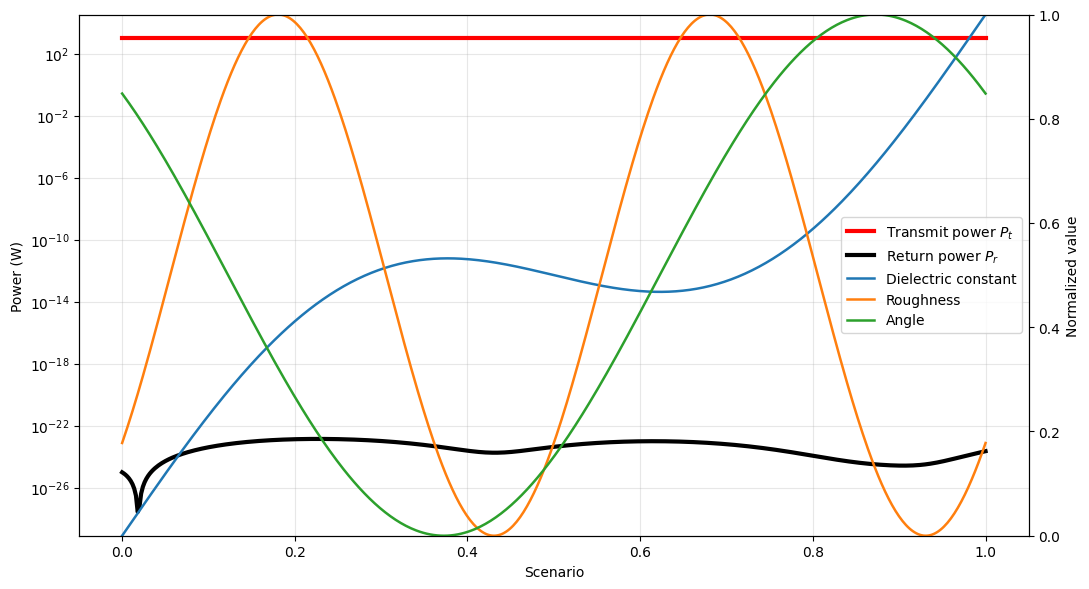

Dielectric constant range: 2.00 to 20.00
Roughness range:           0.20 to 2.00
Angle range:               15.00° to 70.00°
Transmit power:            1000.0 W
Return power range:        2.663e-28 to 1.388e-23 W


In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt

Pt = 1000.0       # transmitted power, W
Gt = 30.0         # transmit gain
Gr = 30.0         # receive gain
lam = 0.24        # wavelength, m
R = 800000.0      # range, m
L = 2.0           # loss factor
sigma_base = 1.0  # baseline radar cross section, m²

def received_power(Pt, Gt, Gr, lam, sigma_eff, R, L):
    return Pt * Gt * Gr * (lam**2 * sigma_eff) / (((4 * math.pi)**3) * (R**4) * L)

def R_vv(eps_r, theta_deg):
    theta = math.radians(theta_deg)
    root_term = max(eps_r - math.sin(theta)**2, 1e-12)
    num = eps_r * math.cos(theta) - math.sqrt(root_term)
    den = eps_r * math.cos(theta) + math.sqrt(root_term)
    return num / den

def normalize(arr):
    arr = np.asarray(arr)
    return (arr - arr.min()) / (arr.max() - arr.min())

x = np.linspace(0, 1, 500)

eps_r = 2.0 + 18.0 * x + 4.0 * np.sin(2 * np.pi * x)
rough = 0.2 + 1.8 * (0.5 + 0.5 * np.sin(4 * np.pi * x - 0.7))
theta = 15.0 + 55.0 * (0.5 + 0.5 * np.cos(2 * np.pi * x + 0.8))

eps_r = np.clip(eps_r, 1.2, None)
rough = np.clip(rough, 0.05, None)
theta = np.clip(theta, 1.0, 89.0)

Pr = []

for e, rgh, th in zip(eps_r, rough, theta):
    rvv = R_vv(e, th)
    fresnel_power_fraction = abs(rvv)**2
    sigma_eff = sigma_base * fresnel_power_fraction * rgh
    sigma_eff = max(sigma_eff, 1e-18)  # avoid zero on log axis
    Pr.append(received_power(Pt, Gt, Gr, lam, sigma_eff, R, L))

Pr = np.array(Pr)

Pt_line = np.full_like(x, Pt)

eps_norm = normalize(eps_r)
rough_norm = normalize(rough)
theta_norm = normalize(theta)

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Left y-axis: power
ax1.plot(x, Pt_line, linewidth=3, color="red", label="Transmit power $P_t$")
ax1.plot(x, Pr, linewidth=3, color="black", label="Return power $P_r$")
ax1.set_yscale("log")
ax1.set_xlabel("Scenario")
ax1.set_ylabel("Power (W)")

# Right y-axis: normalized controls
ax2.plot(x, eps_norm, linewidth=1.8, label="Dielectric constant")
ax2.plot(x, rough_norm, linewidth=1.8, label="Roughness")
ax2.plot(x, theta_norm, linewidth=1.8, label="Angle")
ax2.set_ylabel("Normalized value")
ax2.set_ylim(0, 1)

ax1.grid(True, which="both", alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

print(f"Dielectric constant range: {eps_r.min():.2f} to {eps_r.max():.2f}")
print(f"Roughness range:           {rough.min():.2f} to {rough.max():.2f}")
print(f"Angle range:               {theta.min():.2f}° to {theta.max():.2f}°")
print(f"Transmit power:            {Pt} W")
print(f"Return power range:        {Pr.min():.3e} to {Pr.max():.3e} W")

(ברכות ו א) תניא, אבא בנימין אומר: אין תפלה של אדם נשמעת אלא בבית הכנסת, שנאמר: ״לשמע אל הרנה ואל התפלה״. במקום רנה — שם תהא תפלה

$$
\sigma_{\text{dihedral,max}} \approx \frac{8\pi a^4}{\lambda^2}
$$

- $a$ (m)
- $\lambda$ (m)

$$
\sigma_{\text{trihedral,max}} = \frac{4\pi l^4}{3\lambda^2}
$$

- $l$ (m)
- $\lambda$ (m)